In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
## Import Libraries
# Object manipulation
import statistics
import numpy as np
import pandas as pd
import xgboost as xgb
from collections import defaultdict
from scipy.stats import uniform

# Plot
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.figure_factory as ff
import seaborn as sns

# Scikit-Learn libraries
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn import tree
from sklearn.datasets import make_blobs
from sklearn import datasets
from sklearn.tree import plot_tree

# Analysis
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix

# Optimisation
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV


In [3]:
orders = pd.read_csv("/content/drive/My Drive/Y3S1/AI SOLUTION DEVELOPMENT PROJECT (EGT309)/final_merged_olist_with_geolocationV4.csv")
orders.head()

,total_spent,shipping_fee,avg_review,unique_categories,total_items,delivery_time_days,customer_state,repeat_buyer
0,141.90,12.00,5.0,1,1,6.0,SP,0
1,27.19,8.29,4.0,1,1,3.0,SP,0
2,86.22,17.22,3.0,1,1,25.0,SC,0
3,43.62,17.63,4.0,1,1,20.0,PA,0
4,196.89,16.89,5.0,1,1,13.0,SP,0


In [4]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92752 entries, 0 to 92751
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   total_spent         92752 non-null  float64
 1   shipping_fee        92752 non-null  float64
 2   avg_review          92752 non-null  float64
 3   unique_categories   92752 non-null  int64  
 4   total_items         92752 non-null  int64  
 5   delivery_time_days  92752 non-null  float64
 6   customer_state      92752 non-null  object 
 7   repeat_buyer        92752 non-null  int64  
dtypes: float64(4), int64(3), object(1)
memory usage: 5.7+ MB


In [5]:
orders.columns

Index(['total_spent', 'shipping_fee', 'avg_review', 'unique_categories',
       'total_items', 'delivery_time_days', 'customer_state', 'repeat_buyer'],
      dtype='object')

In [6]:
# Encode categorical columns
le = LabelEncoder()
orders["customer_state"] = le.fit_transform(orders["customer_state"])

# Features and labels
X = orders.drop(columns=["repeat_buyer"])
y = orders["repeat_buyer"]

In [31]:
# check class separation
orders['repeat_buyer'].value_counts()

,count
repeat_buyer,
0,89988
1,2764


### XG Boost

In [7]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

# Drop non-numeric columns from X_train and X_test
object_columns = X_train.select_dtypes(include='object').columns
X_train = X_train.drop(columns=object_columns)
X_test = X_test.drop(columns=object_columns)

# Initialize and train model
model = XGBClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print(classification_report(y_test, y_pred))
print('\n')
print('Accuracy: ', accuracy_score(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99     26997
           1       0.88      0.64      0.74       829

    accuracy                           0.99     27826
   macro avg       0.94      0.82      0.87     27826
weighted avg       0.99      0.99      0.99     27826



Accuracy:  0.9867749586717458


In [10]:
# Make predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Placeholder for measure_error function (replace with your actual implementation)
def measure_error(y_true, y_pred, label):
    # Calculate error metrics here (e.g., accuracy, precision, recall, f1-score)
    # Return a pandas Series or DataFrame with the results
    return pd.Series({'accuracy':accuracy_score(y_true, y_pred),
                      'precision': precision_score(y_true, y_pred),
                      'recall': recall_score(y_true, y_pred),
                      'f1': f1_score(y_true, y_pred)},
                      name=label)
# Combine error metrics
train_test_full_error = pd.concat([
    measure_error(y_train, y_train_pred, 'train'),
    measure_error(y_test, y_test_pred, 'test')
], axis=1)

# Display results
train_test_full_error

,train,test
accuracy,0.991406,0.986775
precision,0.950294,0.884808
recall,0.750904,0.639324
f1,0.838915,0.742297


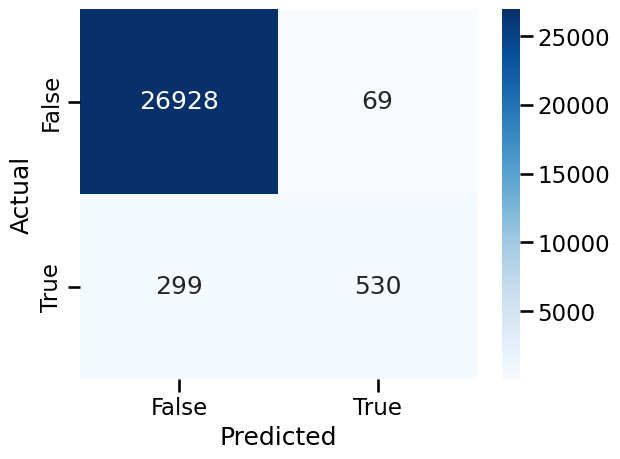

In [11]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.set_context('talk')
ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
labels = ['False', 'True']
ax.set_xticklabels(labels);
ax.set_yticklabels(labels);
ax.set_ylabel('Actual');
ax.set_xlabel('Predicted');

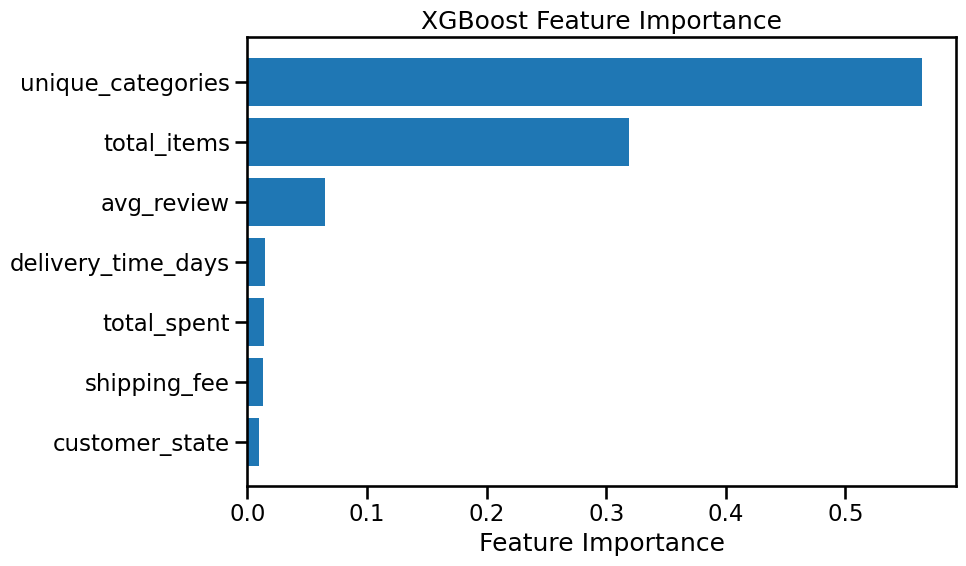

In [12]:
# Get feature importances from the trained XGBoost model
importances = model.feature_importances_
feature_names = X.columns

# Create a DataFrame for plotting
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# Plotting
plt.figure(figsize=(10, 6))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.xlabel("Feature Importance")
plt.title("XGBoost Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Optimisation using RandomSearch

In [13]:
param_dist = {
    'n_estimators': range(50, 201),
    'learning_rate': uniform(0.01, 0.3)  # draw floats from 0.01 to 0.31
}

random_search = RandomizedSearchCV(
    estimator=XGBClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=20,  # number of combinations to try
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

# Fit to training data
random_search.fit(X_train, y_train)

# Best estimator and parameters
best_model = random_search.best_estimator_
print("Best Parameters:", random_search.best_params_)

# Predict with best model
y_pred = best_model.predict(X_test)

# Evaluate
print(classification_report(y_test, y_pred))


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters: {'learning_rate': np.float64(0.22659963168004743), 'n_estimators': 87}
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     26997
           1       0.89      0.64      0.74       829

    accuracy                           0.99     27826
   macro avg       0.94      0.82      0.87     27826
weighted avg       0.99      0.99      0.99     27826



In [14]:
best_params = random_search.best_params_
import json

# Convert NumPy types to native Python types
cleaned_params = {k: float(v) if hasattr(v, 'item') else v for k, v in best_params.items()}
with open("best_xgb_params.json", "w") as f:
    json.dump(cleaned_params, f)
from google.colab import files
files.download("best_xgb_params.json")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

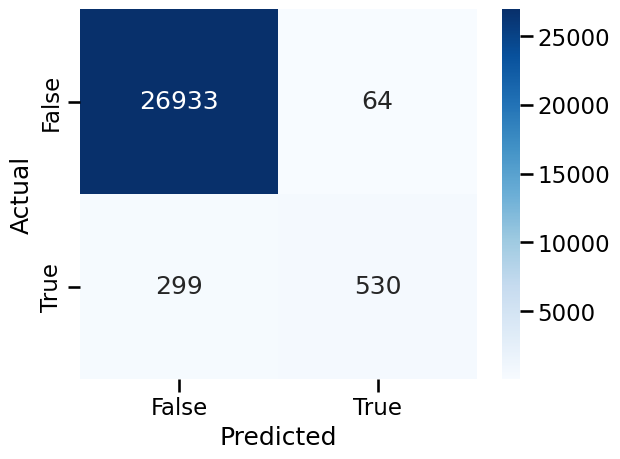

In [15]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.set_context('talk')
ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
labels = ['False', 'True']
ax.set_xticklabels(labels);
ax.set_yticklabels(labels);
ax.set_ylabel('Actual');
ax.set_xlabel('Predicted');

In [16]:
# Make predictions
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

# Combine error metrics
train_test_full_error = pd.concat([
    measure_error(y_train, y_train_pred, 'train'),
    measure_error(y_test, y_test_pred, 'test')
], axis=1)

# Display results
train_test_full_error

,train,test
accuracy,0.989419,0.986955
precision,0.932133,0.892256
recall,0.695607,0.639324
f1,0.796685,0.744905


In [17]:
from sklearn.metrics import precision_recall_curve

# Get predicted probabilities for the positive class (Repeat Buyer = 1)
y_train_pred_prob = best_model.predict_proba(X_train)
y_train_scores = y_train_pred_prob[:, 1]  # Probabilities for class 1

# Compute precision-recall curve
precisions, recalls, thresholds = precision_recall_curve(y_train, y_train_scores)


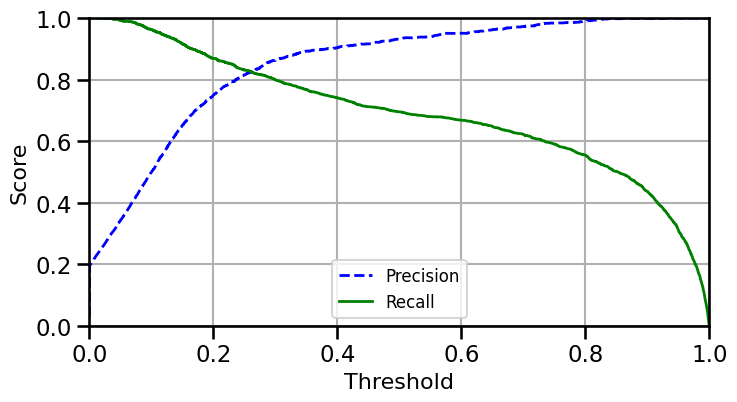

In [18]:
def plot_precision_recall_curve(precisions, recalls, thresholds):
    plt.figure(figsize=(8, 4))  # Make sure this is called before plotting
    plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
    plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
    plt.xlabel("Threshold", fontsize=16)
    plt.ylabel("Score", fontsize=16)
    plt.legend(loc="lower center", fontsize=12)
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.grid(True)
plot_precision_recall_curve(precisions, recalls, thresholds)
plt.show()


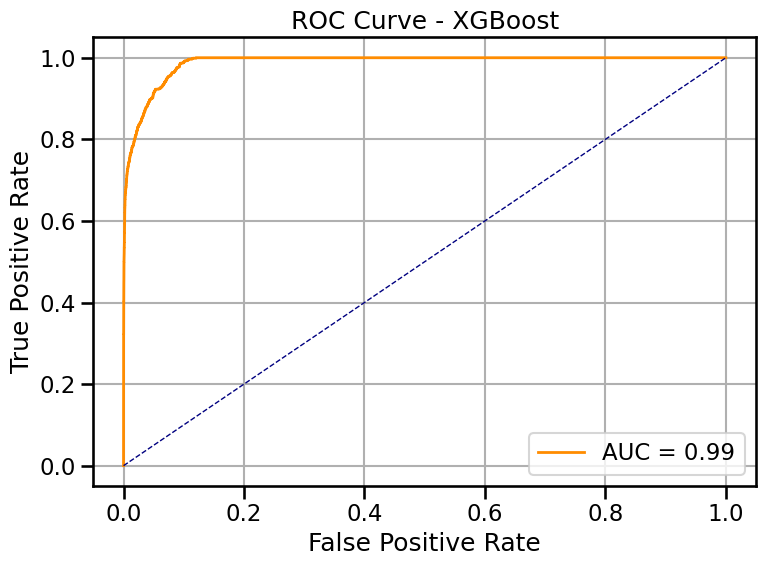

In [19]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get predicted probabilities for class 1 (positive class)
y_probs = best_model.predict_proba(X_test)[:, 1]

# Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="darkorange", lw=2, label="AUC = %0.2f" % roc_auc)
plt.plot([0, 1], [0, 1], color="navy", lw=1, linestyle="--")  # Diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


In [20]:
import joblib
joblib.dump(best_model, 'saved_model_XGBoost.pkl')

['saved_model_XGBoost.pkl']

In [21]:
print(y_test.value_counts())

repeat_buyer
0    26997
1      829
Name: count, dtype: int64


In [22]:
import json
with open("best_xgb_params.json") as f:
    notebook_params = json.load(f)
print("✅ Notebook Best Params:", notebook_params)


✅ Notebook Best Params: {'learning_rate': 0.22659963168004743, 'n_estimators': 87}


In [23]:
X_train = pd.get_dummies(X_train, prefix="state", columns=["customer_state"])
X_test = pd.get_dummies(X_test, prefix="state", columns=["customer_state"])


In [24]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)


X_train shape: (64926, 33)
X_test shape: (27826, 33)


In [25]:
# Add missing columns in X_test that exist in X_train
for col in X_train.columns:
    if col not in X_test.columns:
        X_test[col] = 0

# Drop any extra columns in X_test that don't exist in X_train
X_test = X_test[X_train.columns]


In [26]:
assert list(X_train.columns) == list(X_test.columns), "Column mismatch still exists!"


In [27]:
print("[DEBUG] LabelEncoder classes:", list(le.classes_))

[DEBUG] LabelEncoder classes: ['AC', 'AL', 'AM', 'AP', 'BA', 'CE', 'DF', 'ES', 'GO', 'MA', 'MG', 'MS', 'MT', 'PA', 'PB', 'PE', 'PI', 'PR', 'RJ', 'RN', 'RO', 'RR', 'RS', 'SC', 'SE', 'SP', 'TO']


In [28]:
encoding_map = dict(zip(le.classes_, le.transform(le.classes_)))

In [29]:
print("[DEBUG] customer_state encoding map:", encoding_map)


[DEBUG] customer_state encoding map: {'AC': np.int64(0), 'AL': np.int64(1), 'AM': np.int64(2), 'AP': np.int64(3), 'BA': np.int64(4), 'CE': np.int64(5), 'DF': np.int64(6), 'ES': np.int64(7), 'GO': np.int64(8), 'MA': np.int64(9), 'MG': np.int64(10), 'MS': np.int64(11), 'MT': np.int64(12), 'PA': np.int64(13), 'PB': np.int64(14), 'PE': np.int64(15), 'PI': np.int64(16), 'PR': np.int64(17), 'RJ': np.int64(18), 'RN': np.int64(19), 'RO': np.int64(20), 'RR': np.int64(21), 'RS': np.int64(22), 'SC': np.int64(23), 'SE': np.int64(24), 'SP': np.int64(25), 'TO': np.int64(26)}


In [30]:
print("Full‐data counts:",   y.value_counts().to_dict())
print("Train‐set counts:",  y_train.value_counts().to_dict())
print("Test‐set counts:",   y_test.value_counts().to_dict())

Full‐data counts: {0: 89988, 1: 2764}
Train‐set counts: {0: 62991, 1: 1935}
Test‐set counts: {0: 26997, 1: 829}
